In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("data.csv")
data

,SMILES,mg/L
0,c1ccccc1,1840.00000
1,c1c2ccccc2ccc1,31.60000
2,c1c2cc3cc4ccccc4cc3cc2ccc1,0.00151


In [3]:
from rdkit.Chem.Descriptors import MolWt
from rdkit.Chem import MolFromSmiles
import numpy as np

In [4]:
g_per_mg = 1 / 1000
g_ancene_per_mol = [MolWt(MolFromSmiles(s)) for s in data["SMILES"]]
data["logS"] = np.log10(data["mg/L"] * g_per_mg / np.array(g_ancene_per_mol))

In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

aromatic_query = Chem.MolFromSmarts("a")

def calc_ap(mol):
    return len(mol.GetSubstructMatches(aromatic_query)) / mol.GetNumAtoms()

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "mw": Descriptors.MolWt(mol),
        "logp": Crippen.MolLogP(mol),
        "rotors": Lipinski.NumRotatableBonds(mol),
        "ap": calc_ap(mol),
    }

In [6]:
def esol_refitted(smiles):
    descs = calc_descriptors(smiles)
    if descs is None:
        return None
    return (
        -2.5600786186333955
        + -0.0025243511123795846 * descs["mw"]
        + -0.3508139867122456 * descs["logp"]
        + 0.019884855485735597 * descs["rotors"]
        + -0.3276395438590812 * descs["ap"]
    )

In [7]:
esol_preds = data["SMILES"].apply(esol_refitted)

In [8]:
chemeleon_preds = pd.read_csv("chemeleon_pred.csv")["logS"].values

In [9]:
number_of_rings = [1, 2, 3]

/tmp/ipykernel_354871/2299043300.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(["", "Benzene", "", "Naphthalene", "", "Anthracene"])


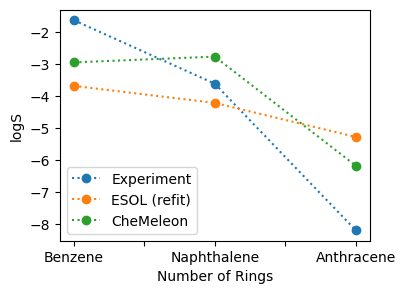

In [10]:
# plot true, esol, and chemeleon predictions against chain length
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 3))
plt.plot(number_of_rings, data["logS"], label="Experiment", marker="o", linestyle=':')
plt.plot(number_of_rings, esol_preds, label="ESOL (refit)", marker="o", linestyle=':')
plt.plot(number_of_rings, chemeleon_preds, label="CheMeleon", marker="o", linestyle=':')
plt.xlabel("Number of Rings")
plt.gca().set_xticklabels(["", "Benzene", "", "Naphthalene", "", "Anthracene"])
plt.ylabel("logS")
plt.legend()

In [11]:
print("RMSE of ESOL refitted:", np.sqrt(np.mean((esol_preds - data["logS"]) ** 2)))
print("RMSE of Chemeleon:", np.sqrt(np.mean((chemeleon_preds - data["logS"]) ** 2)))

RMSE of ESOL refitted: 2.0836916884322854
RMSE of Chemeleon: 1.4725743892855823
